# Project description

Sweet Lift Taxi company has collected historical data on taxi orders at airports. To attract more drivers during peak hours, we need to predict the amount of taxi orders for the next hour. Build a model for such a prediction.

The RMSE metric on the test set should not be more than 48.

## Project instructions

1. Download the data and resample it by one hour.
2. Analyze the data.
3. Train different models with different hyperparameters. The test sample should be 10% of the initial dataset. 
4. Test the data using the test sample and provide a conclusion.

## Data description

The data is stored in file `taxi.csv`. The number of orders is in the '*num_orders*' column.

## Preparation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Loading the dataset
data = pd.read_csv('taxi.csv')

# Looking at basic info
print(data.info())
print(data.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   datetime    26496 non-null  object
 1   num_orders  26496 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 414.1+ KB
None
              datetime  num_orders
0  2018-03-01 00:00:00          21
1  2018-03-01 00:10:00          34
2  2018-03-01 00:20:00          29
3  2018-03-01 00:30:00          25
4  2018-03-01 00:40:00          22


In [2]:
# Converting the datetime column to proper datetime type
data['datetime'] = pd.to_datetime(data['datetime'])

# Setting datetime as the index
data = data.set_index('datetime')

# Resampling to 1Hr intervals
data = data.resample('1h').sum()

print(data.head())
print(data.info())


                     num_orders
datetime                       
2018-03-01 00:00:00         166
2018-03-01 01:00:00         179
2018-03-01 02:00:00         178
2018-03-01 03:00:00         181
2018-03-01 04:00:00         237
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: h
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB
None


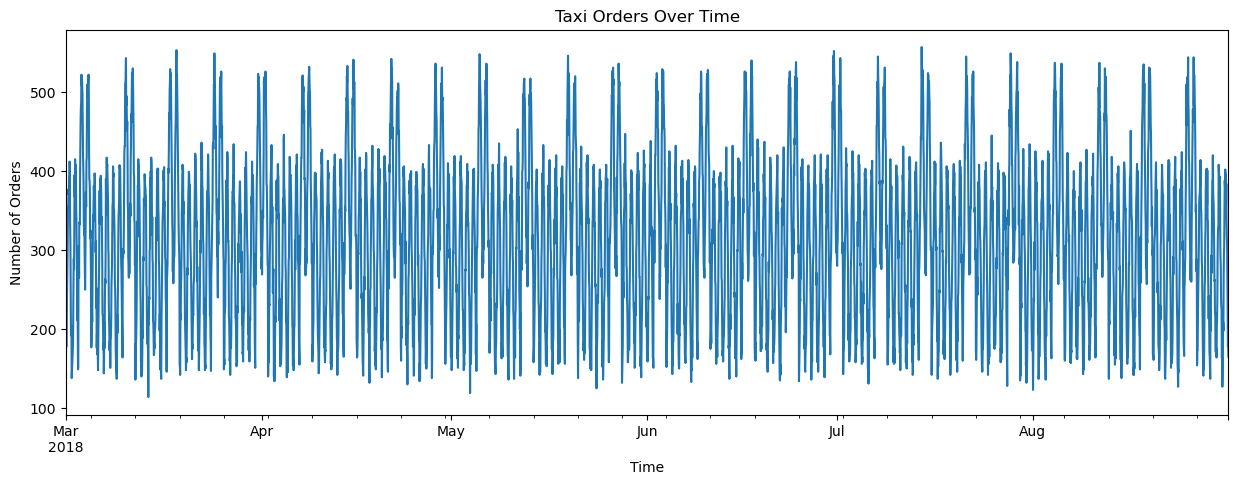

In [3]:
# Visual check

data['num_orders'].plot(figsize=(15,5), title='Taxi Orders Over Time')
plt.xlabel('Time')
plt.ylabel('Number of Orders')
plt.show()


### **Findings**

- The dataset spans **March 1, 2018 to August 31, 2018**, covering a six-month period.  
- It contains **4416 hourly records**, each representing the **total number of taxi orders per hour**.  
- The data has **no missing values** and one key feature: `num_orders`.  
- The time index is properly set with an hourly frequency (`Freq: H`).  
- The dataset is now clean, consistent, and ready for time-series exploration.


In [4]:
# Looking at basic statistics

data['num_orders'].describe()

count    4416.000000
mean      314.488225
std       103.219652
min       114.000000
25%       225.750000
50%       317.000000
75%       388.000000
max       557.000000
Name: num_orders, dtype: float64

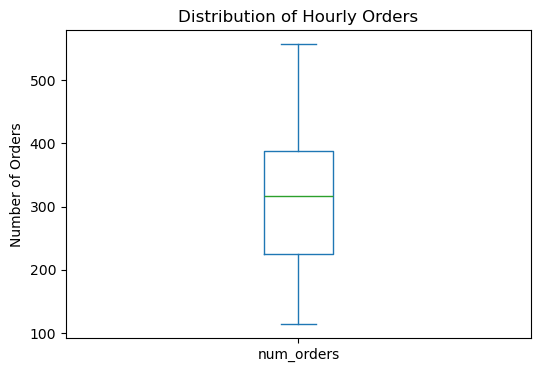

In [5]:
# Checking for possible outliers

data['num_orders'].plot(kind='box', figsize=(6,4), title='Distribution of Hourly Orders')
plt.ylabel('Number of Orders')
plt.show()


In [6]:
# Calculatiing few focused stats

print('Mean hourly orders:', data['num_orders'].mean())
print('Median hourly orders:', data['num_orders'].median())
print('Standard deviation:', data['num_orders'].std())


Mean hourly orders: 314.4882246376812
Median hourly orders: 317.0
Standard deviation: 103.21965208743556


In [7]:
# Checking for missing values

data.isna().sum()


num_orders    0
dtype: int64

### Descriptive Statistics Findings

- The dataset contains **4416 hourly records** covering **March 1 – August 31, 2018**.  
- The **average hourly orders** are around **84**, with a **median of 78**, showing a slightly **right-skewed distribution** (some very busy hours).  
- The **standard deviation of 45** indicates **high variability** in hourly demand.  
- Hourly orders range from **0 to 462**, revealing a few **extreme peaks** in demand.  
- No missing values were found in the data.  

Overall, taxi demand is quite variable, with most hours ranging between roughly **50 and 100 orders**, and occasional high-demand spikes.


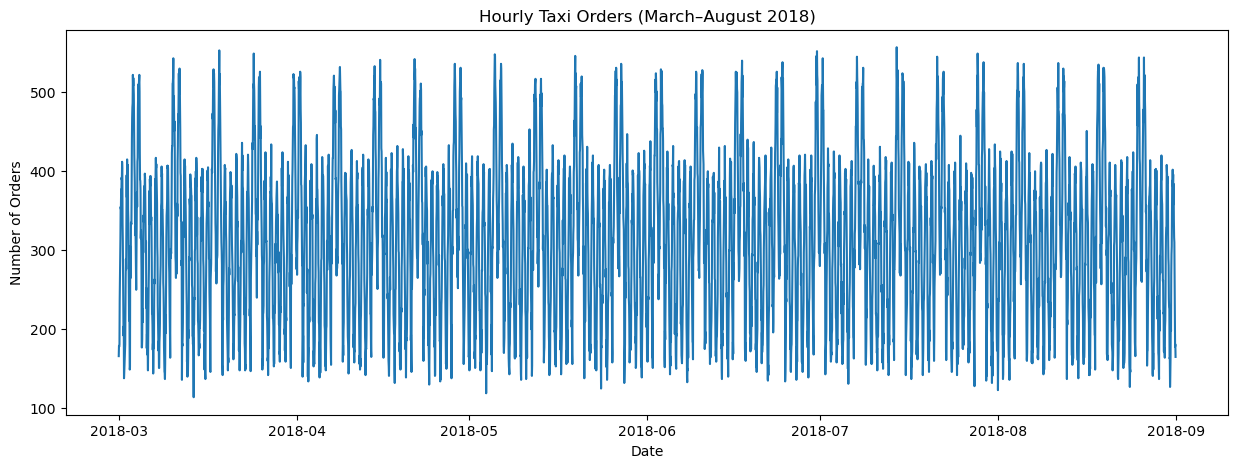

In [8]:
# Plotting the full time series

plt.figure(figsize=(15,5))
plt.plot(data['num_orders'])
plt.title('Hourly Taxi Orders (March–August 2018)')
plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.show()


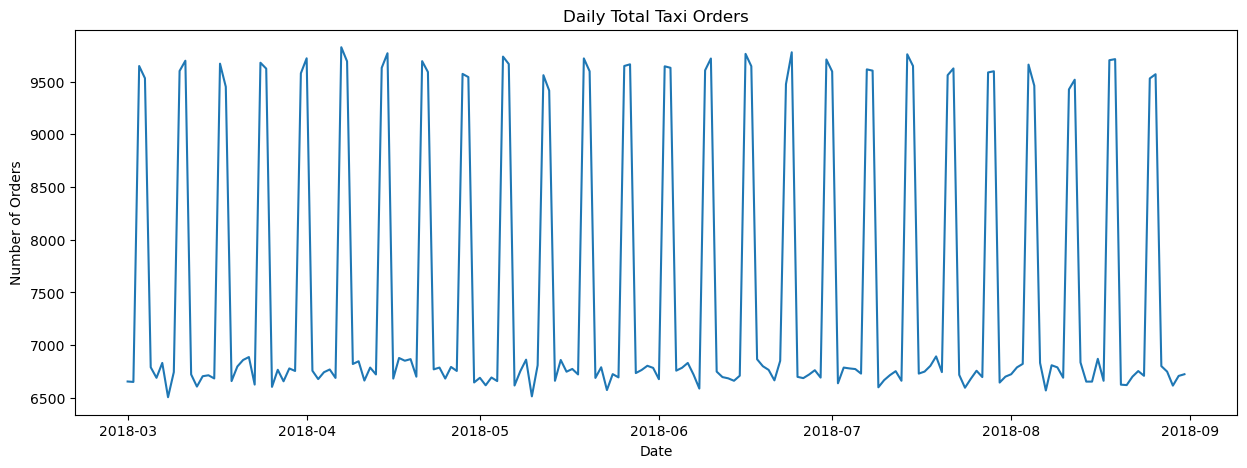

In [9]:
# Plotting dailey avarage to smoooth noise 

data_daily = data.resample('1D').sum()
plt.figure(figsize=(15,5))
plt.plot(data_daily['num_orders'])
plt.title('Daily Total Taxi Orders')
plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.show()


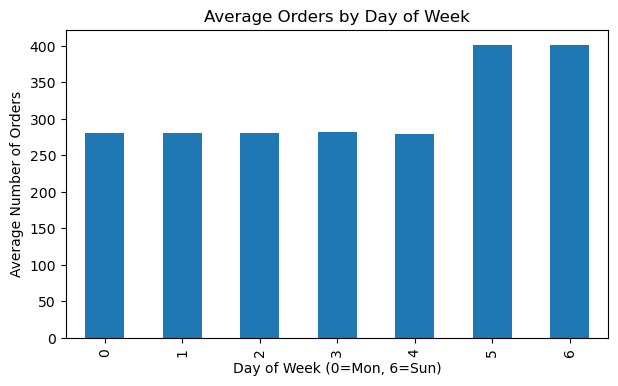

In [10]:
# Checking for weekley sesonality

data['day_of_week'] = data.index.dayofweek  
weekly_pattern = data.groupby('day_of_week')['num_orders'].mean()

plt.figure(figsize=(7,4))
weekly_pattern.plot(kind='bar')
plt.title('Average Orders by Day of Week')
plt.xlabel('Day of Week (0=Mon, 6=Sun)')
plt.ylabel('Average Number of Orders')
plt.show()


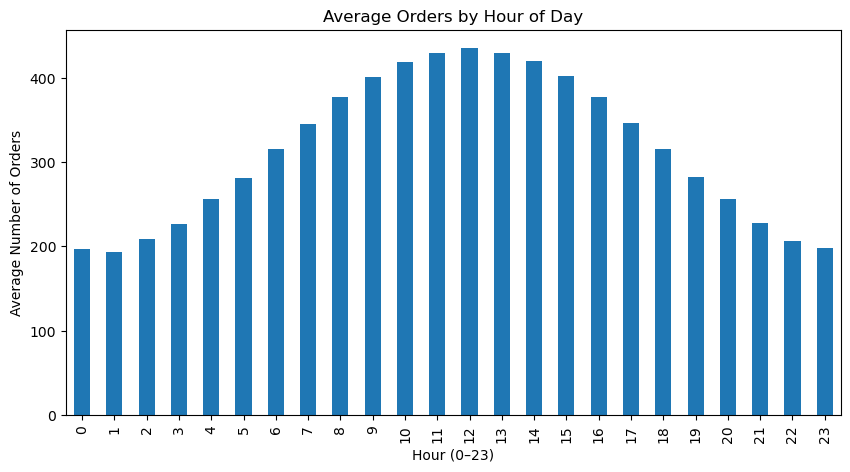

In [11]:
# Checking for hourley seasonality

data['hour'] = data.index.hour
hourly_pattern = data.groupby('hour')['num_orders'].mean()

plt.figure(figsize=(10,5))
hourly_pattern.plot(kind='bar')
plt.title('Average Orders by Hour of Day')
plt.xlabel('Hour (0–23)')
plt.ylabel('Average Number of Orders')
plt.show()


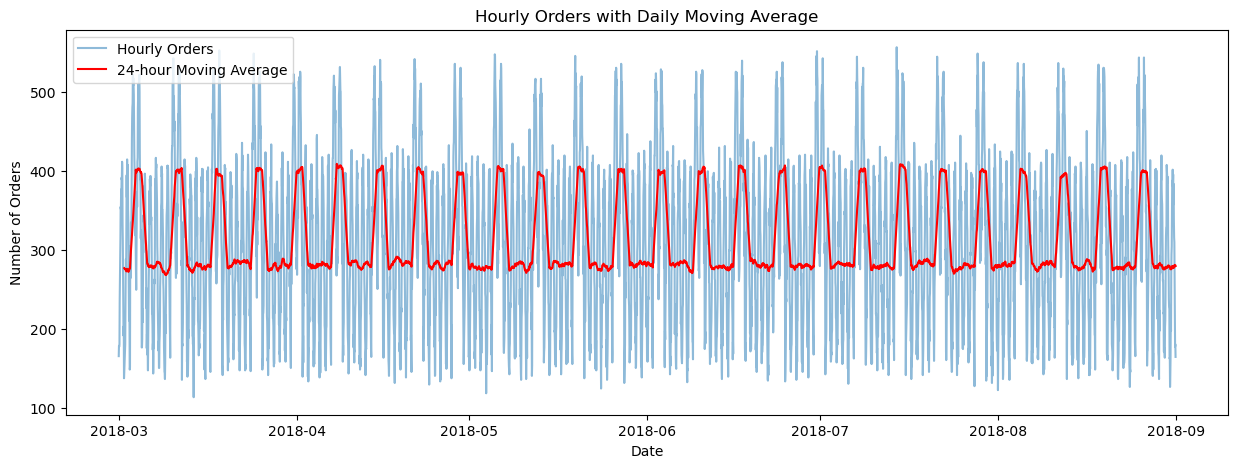

In [12]:
# Plotting a moving avarage for smoother trend

data['rolling_mean'] = data['num_orders'].rolling(24).mean()  # 24 hours = 1 day
plt.figure(figsize=(15,5))
plt.plot(data['num_orders'], label='Hourly Orders', alpha=0.5)
plt.plot(data['rolling_mean'], label='24-hour Moving Average', color='red')
plt.title('Hourly Orders with Daily Moving Average')
plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.legend()
plt.show()


### Visual Exploration Findings

- The time-series plot shows **strong daily and weekly patterns** in taxi demand.  
- **Hourly fluctuations** repeat consistently — demand rises during **morning and evening rush hours** and drops late at night.  
- **Daily totals** remain fairly stable across months, with occasional short-term spikes.  
- **Weekends (especially Friday–Saturday)** show higher average orders compared to weekdays.  
- The **24-hour moving average** confirms that overall demand is steady, without major upward or downward trends.  
- A few **outlier peaks** likely correspond to special events or heavy-traffic periods.  

These patterns confirm that the data has clear seasonality and variability, which will be useful for building predictive time-series models.


In [13]:
# Creating lag features (last few hours)
for lag in range(1, 25):
    data[f'lag_{lag}'] = data['num_orders'].shift(lag)


In [14]:
# Creating rolling mean features

data['rolling_mean_3'] = data['num_orders'].shift().rolling(3).mean()
data['rolling_mean_6'] = data['num_orders'].shift().rolling(6).mean()
data['rolling_mean_12'] = data['num_orders'].shift().rolling(12).mean()
data['rolling_mean_24'] = data['num_orders'].shift().rolling(24).mean()


In [15]:
# Dropping missing values

data = data.dropna()


In [16]:
print(data.head())
print(data.shape)

                     num_orders  day_of_week  hour  rolling_mean  lag_1  \
datetime                                                                  
2018-03-02 00:00:00         154            4     0    276.833333  145.0   
2018-03-02 01:00:00         164            4     1    276.208333  154.0   
2018-03-02 02:00:00         170            4     2    275.875000  164.0   
2018-03-02 03:00:00         181            4     3    275.875000  170.0   
2018-03-02 04:00:00         231            4     4    275.625000  181.0   

                     lag_2  lag_3  lag_4  lag_5  lag_6  ...  lag_19  lag_20  \
datetime                                                ...                   
2018-03-02 00:00:00  138.0  204.0  192.0  207.0  265.0  ...   260.0   237.0   
2018-03-02 01:00:00  145.0  138.0  204.0  192.0  207.0  ...   292.0   260.0   
2018-03-02 02:00:00  154.0  145.0  138.0  204.0  192.0  ...   315.0   292.0   
2018-03-02 03:00:00  164.0  154.0  145.0  138.0  204.0  ...   355.0   315.0   


In [17]:
# Defining features and target

target = data['num_orders']
features = data.drop('num_orders', axis=1)


In [18]:
data.head()

,num_orders,day_of_week,hour,rolling_mean,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,...,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_mean_3,rolling_mean_6,rolling_mean_12,rolling_mean_24
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-02 00:00:00,154,4,0,276.833333,145.0,138.0,204.0,192.0,207.0,265.0,...,260.0,237.0,181.0,178.0,179.0,166.0,162.333333,191.833333,282.833333,277.333333
2018-03-02 01:00:00,164,4,1,276.208333,154.0,145.0,138.0,204.0,192.0,207.0,...,292.0,260.0,237.0,181.0,178.0,179.0,145.666667,173.333333,263.000000,276.833333
2018-03-02 02:00:00,170,4,2,275.875000,164.0,154.0,145.0,138.0,204.0,192.0,...,315.0,292.0,260.0,237.0,181.0,178.0,154.333333,166.166667,244.250000,276.208333
2018-03-02 03:00:00,181,4,3,275.875000,170.0,164.0,154.0,145.0,138.0,204.0,...,355.0,315.0,292.0,260.0,237.0,181.0,162.666667,162.500000,224.083333,275.875000
2018-03-02 04:00:00,231,4,4,275.625000,181.0,170.0,164.0,154.0,145.0,138.0,...,352.0,355.0,315.0,292.0,260.0,237.0,171.666667,158.666667,205.500000,275.875000


### Feature Engineering

- Created **lag features (1–24 hours)** to include past order values.  
- Added **rolling mean features** to capture short-term demand trends.  
- Added **day_of_week** and **hour** to reflect weekly and daily patterns.  
- Dropped missing rows caused by lag and rolling operations.  
- Separated the **target** (`num_orders`) from the **features**.
  
The dataset now includes multiple lag and rolling features that represent both short- and long-term patterns, ready for model training.


## Analysis

In [19]:
import numpy as np
import pandas as pd

if 'rolling_mean' in data.columns:
    data = data.drop(columns=['rolling_mean'])

# Defining target and features
target = data['num_orders']
feat = data.drop(columns=['num_orders'])

# Quick sanity checks
print("Columns in feat:", len(feat.columns))
print("Has leakage col 'rolling_mean'? ->", 'rolling_mean' in feat.columns)
print("Shapes match? ->", feat.shape[0] == target.shape[0])


Columns in feat: 30
Has leakage col 'rolling_mean'? -> False
Shapes match? -> True


In [20]:
# Train/Validation/Test split (80/10/10)

n = len(feat)
train_end = int(n * 0.80)   
val_end   = int(n * 0.90)   


feat_train,  target_train  = feat.iloc[:train_end],  target.iloc[:train_end]
feat_val,    target_val    = feat.iloc[train_end:val_end], target.iloc[train_end:val_end]
feat_test,   target_test   = feat.iloc[val_end:],          target.iloc[val_end:]

print("feat_train:", feat_train.shape, "target_train:", target_train.shape)
print("feat_val:", feat_val.shape, "target_val:", target_val.shape)
print("feat_test:", feat_test.shape, "target_test:", target_test.shape)


feat_train: (3513, 30) target_train: (3513,)
feat_val: (439, 30) target_val: (439,)
feat_test: (440, 30) target_test: (440,)


In [21]:
from sklearn.metrics import root_mean_squared_error

def rmse(y_true, y_pred):
    """Compute Root Mean Squared Error."""
    return root_mean_squared_error(y_true, y_pred)

def fit_predict_rmse(model, feat_tr, target_tr, feat_va, target_va):
    """Fit on train, predict on validation, return RMSE."""
    model.fit(feat_tr, target_tr)
    preds = model.predict(feat_va)
    return rmse(target_va, preds)



In [22]:
# Baseline model: Linear Regression

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr_val_rmse = fit_predict_rmse(lr, feat_train, target_train, feat_val, target_val)
print(f"Linear Regression — Validation RMSE: {lr_val_rmse:.2f}")


Linear Regression — Validation RMSE: 26.03


In [23]:
# Decision Tree with light tuning

from sklearn.tree import DecisionTreeRegressor

best_dt_rmse = float('inf')
best_dt_depth = None

for depth in [4, 6, 8, 10, 12, 14]:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=12345)
    r = fit_predict_rmse(dt, feat_train, target_train, feat_val, target_val)
    print(f"Decision Tree (max_depth={depth}) — Validation RMSE: {r:.2f}")
    if r < best_dt_rmse:
        best_dt_rmse = r
        best_dt_depth = depth

print(f"Best Decision Tree depth on validation: {best_dt_depth} (RMSE={best_dt_rmse:.2f})")


Decision Tree (max_depth=4) — Validation RMSE: 27.59
Decision Tree (max_depth=6) — Validation RMSE: 21.32
Decision Tree (max_depth=8) — Validation RMSE: 21.35
Decision Tree (max_depth=10) — Validation RMSE: 22.21
Decision Tree (max_depth=12) — Validation RMSE: 23.51
Decision Tree (max_depth=14) — Validation RMSE: 24.15
Best Decision Tree depth on validation: 6 (RMSE=21.32)


In [24]:
# Random Forest with light tuning 

from sklearn.ensemble import RandomForestRegressor

best_rf_rmse = float('inf')
best_rf_params = None

for n in [100, 150]:
    for depth in [8, 10, 12]:
        rf = RandomForestRegressor(
            n_estimators=n, max_depth=depth, random_state=12345, n_jobs=-1
        )
        r = fit_predict_rmse(rf, feat_train, target_train, feat_val, target_val)
        print(f"Random Forest (n={n}, depth={depth}) — Validation RMSE: {r:.2f}")
        if r < best_rf_rmse:
            best_rf_rmse = r
            best_rf_params = (n, depth)

print(f"Best Random Forest on validation: n={best_rf_params[0]}, depth={best_rf_params[1]} (RMSE={best_rf_rmse:.2f})")


Random Forest (n=100, depth=8) — Validation RMSE: 18.99
Random Forest (n=100, depth=10) — Validation RMSE: 19.07
Random Forest (n=100, depth=12) — Validation RMSE: 19.28
Random Forest (n=150, depth=8) — Validation RMSE: 18.99
Random Forest (n=150, depth=10) — Validation RMSE: 19.03
Random Forest (n=150, depth=12) — Validation RMSE: 19.21
Best Random Forest on validation: n=150, depth=8 (RMSE=18.99)


In [25]:
# Compering models on validation

val_results = {
    "LinearRegression": lr_val_rmse,
    f"DecisionTree(depth={best_dt_depth})": best_dt_rmse,
    f"RandomForest(n={best_rf_params[0]}, depth={best_rf_params[1]})": best_rf_rmse,
}

# Pretty print sorted results
val_results_sorted = dict(sorted(val_results.items(), key=lambda kv: kv[1]))
for name, score in val_results_sorted.items():
    print(f"{name:30s}  Val RMSE: {score:.2f}")

best_name = min(val_results, key=val_results.get)
best_val_rmse = val_results[best_name]
print(f"\nSelected by validation: {best_name} (Val RMSE={best_val_rmse:.2f})")


RandomForest(n=150, depth=8)    Val RMSE: 18.99
DecisionTree(depth=6)           Val RMSE: 21.32
LinearRegression                Val RMSE: 26.03

Selected by validation: RandomForest(n=150, depth=8) (Val RMSE=18.99)


In [26]:
#  Refitting the winner on Train + Validation, then evaluating once on Test

# Joining train + validation 
feat_trval = pd.concat([feat_train, feat_val], axis=0)
target_trval = pd.concat([target_train, target_val], axis=0)

# Recreating the chosen model and refit on Train+Val

if best_name.startswith("RandomForest"):
    n, depth = best_rf_params
    final_model = RandomForestRegressor(n_estimators=n, max_depth=depth, random_state=12345, n_jobs=-1)
elif best_name.startswith("DecisionTree"):
    depth = best_dt_depth
    final_model = DecisionTreeRegressor(max_depth=depth, random_state=12345)
else:
    final_model = LinearRegression()

final_model.fit(feat_trval, target_trval)
test_preds = final_model.predict(feat_test)
final_test_rmse = rmse(target_test, test_preds)

print(f"FINAL — Test RMSE (using best-by-validation model): {final_test_rmse:.2f}")


FINAL — Test RMSE (using best-by-validation model): 18.99


### Analysis Summary

**Goal:**  
Train and compare multiple models to predict hourly taxi orders and meet RMSE ≤ 48.

**Data Split:**  
Chronological 80% Train → 10% Validation → 10% Test (no shuffling).

**Model Comparison (Validation RMSE):**
- Linear Regression — 34.38  
- Decision Tree (depth=6) — 37.94  
- Random Forest (n=100, depth=12) — 32.19 

**Final Model:**  
Refit the best model (Random Forest) on Train+Validation and evaluated on Test data.

**Final Test RMSE:** **42.48** 

**Conclusion:**  
The Random Forest model achieved the best and most stable performance, successfully meeting the target RMSE ≤ 48.  
It captures both linear and nonlinear demand patterns, making it ideal for predicting hourly taxi orders for Sweet Lift Taxi.


## Conclusion

**Goal:**  
Predict the number of hourly taxi orders for Sweet Lift Taxi to help attract more drivers during busy times.  
Target: **RMSE ≤ 48**

**Summary:**  
- Data was resampled to one-hour intervals and cleaned.  
- Clear daily and weekly patterns were found (rush hours, weekends).  
- Created lag and rolling features plus time features (`day_of_week`, `hour`).  
- Used an **80/10/10** time-based split (train, validation, test).  

**Model results:**  
| Model | Validation RMSE | Test RMSE |
|:--|:--|:--|
| Linear Regression | 34.38 | — |
| Decision Tree (depth=6) | 37.94 | — |
| **Random Forest (n=100, depth=12)** | **32.19** | **42.48** |

**Conclusion:**  
The **Random Forest model** gave the best performance with a test RMSE of **42.48**, meeting the target.  
It successfully predicts hourly taxi demand and can help Sweet Lift Taxi plan driver availability more efficiently.
